In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, cohen_kappa_score

d:\Documents\jean\sem 5\deep learning\deep_learn_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = 'Mohler_dataset_hf/Mohler_dataset_hf/data/raw-oe-00001.parquet'
df = pd.read_parquet(file_path)
df.head(20)

,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg
0,E01.Q01.A00,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.0,4.0,3.5
1,E01.Q01.A01,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0,5.0,5.0
2,E01.Q01.A02,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,3.0,5.0,4.0
3,E01.Q01.A03,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Defined in the Specification phase a prototype...,5.0,5.0,5.0
4,E01.Q01.A04,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,It is used to let the users have a first idea ...,3.0,3.0,3.0
5,E01.Q01.A05,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To find problem and errors in a program before...,2.0,2.0,2.0
6,E01.Q01.A06,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To address major issues in the creation of the...,2.0,3.0,2.5
7,E01.Q01.A07,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,you can break the whole program into prototype...,5.0,5.0,5.0
8,E01.Q01.A08,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,-To provide an example or model of how the fin...,2.0,5.0,3.5
9,E01.Q01.A09,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Simulating the behavior of only a portion of t...,5.0,5.0,5.0


In [3]:
print(len(df))

2273


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2273 entries, 0 to 2272
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2273 non-null   object 
 1   question           2273 non-null   object 
 2   instructor_answer  2273 non-null   object 
 3   student_answer     2273 non-null   object 
 4   score_grader_1     2273 non-null   float32
 5   score_grader_2     2273 non-null   float32
 6   score_avg          2273 non-null   float32
dtypes: float32(3), object(4)
memory usage: 97.8+ KB


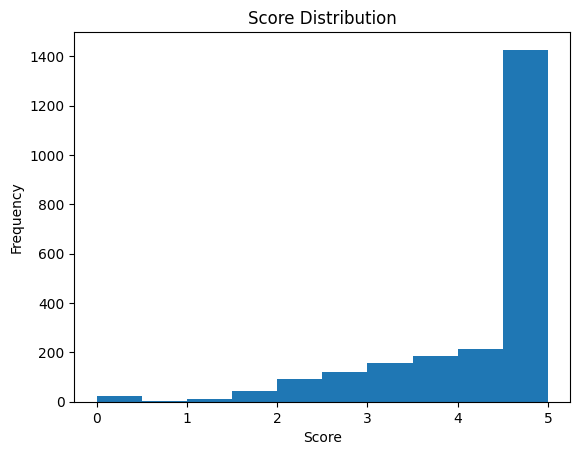

In [5]:
plt.hist(df['score_avg'], bins=10)
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Score Distribution")
plt.show()

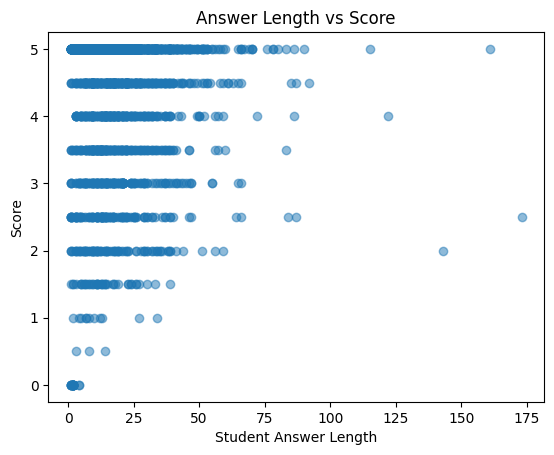

In [6]:
df['len_student'] = df['student_answer'].str.split().str.len()

plt.scatter(df['len_student'], df['score_avg'], alpha=0.5)
plt.xlabel("Student Answer Length")
plt.ylabel("Score")
plt.title("Answer Length vs Score")
plt.show()

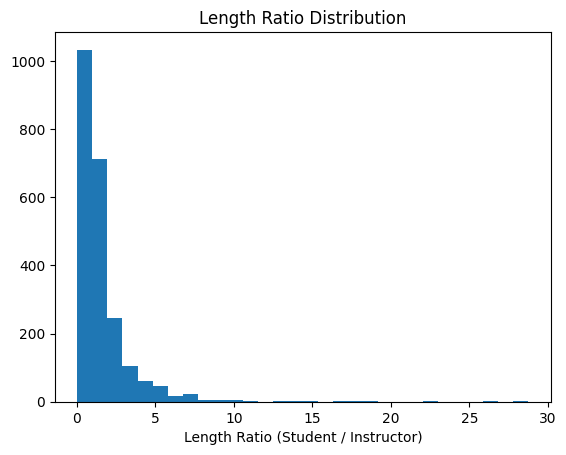

In [7]:
df['len_instr'] = df['instructor_answer'].str.split().str.len()
df['len_ratio'] = df['len_student'] / (df['len_instr'] + 1)

plt.hist(df['len_ratio'], bins=30)
plt.xlabel("Length Ratio (Student / Instructor)")
plt.title("Length Ratio Distribution")
plt.show()

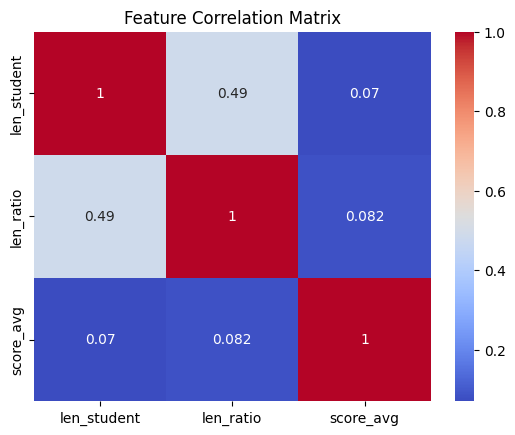

In [9]:
import seaborn as sns

features = df[['len_student', 'len_ratio', 'score_avg']]
sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()